# Exploration de NSL-KDD
Objectif : comprendre les données avant de construire le pipeline.

In [1]:
import sys
sys.path.append("../app-ml")
import matplotlib.pyplot as plt
from ingestion import load_nsl_kdd

train = load_nsl_kdd("../data/raw/KDDTrain+.txt")
test = load_nsl_kdd("../data/raw/KDDTest+.txt")
print(train.shape, test.shape)

(125973, 43) (22544, 43)


## 1. Répartition normal / attaques

train: normal=67343 (53.5%), attaques=58630
test: normal=9711 (43.1%), attaques=12833


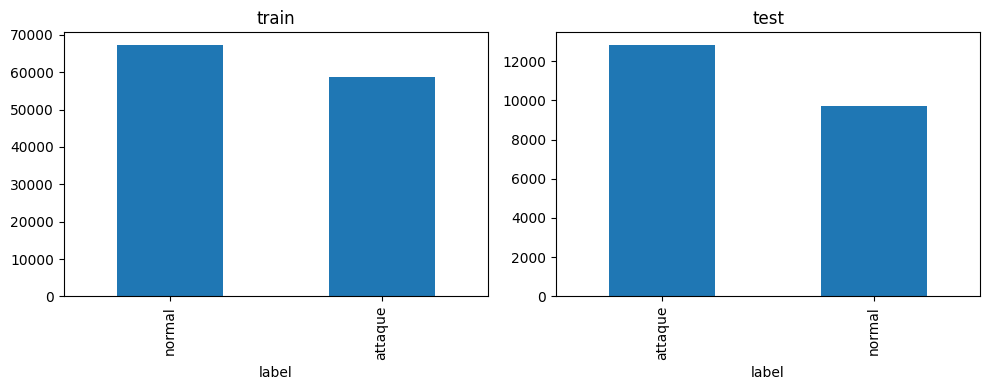

In [2]:
for name, df in [("train", train), ("test", test)]:
    n = (df.label == "normal").sum()
    print(f"{name}: normal={n} ({n/len(df):.1%}), attaques={len(df)-n}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (name, df) in zip(ax, [("train", train), ("test", test)]):
    df.label.eq("normal").map({True: "normal", False: "attaque"}).value_counts().plot.bar(ax=a, title=name)
plt.tight_layout(); plt.show()

## 2. Types d'attaques (top 10)

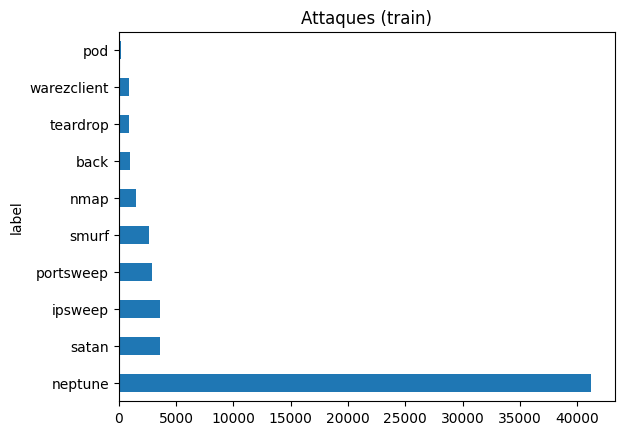

In [3]:
train[train.label != "normal"].label.value_counts().head(10).plot.barh(title="Attaques (train)")
plt.show()

## 3. Attaques présentes dans le test mais absentes du train
Ce sont les attaques « inconnues » : elles mesurent la vraie capacité de généralisation.

In [4]:
unknown = set(test.label) - set(train.label)
print(len(unknown), "attaques inconnues :", sorted(unknown))

17 attaques inconnues : ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


## 4. Variables catégorielles

In [5]:
for c in ["protocol_type", "flag"]:
    print(train[c].value_counts(), "\n")
print("services distincts :", train.service.nunique())

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64 

flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64 

services distincts : 70


## 5. Comparaison normal vs attaque sur quelques variables
Échelle logarithmique car les valeurs sont très étalées.

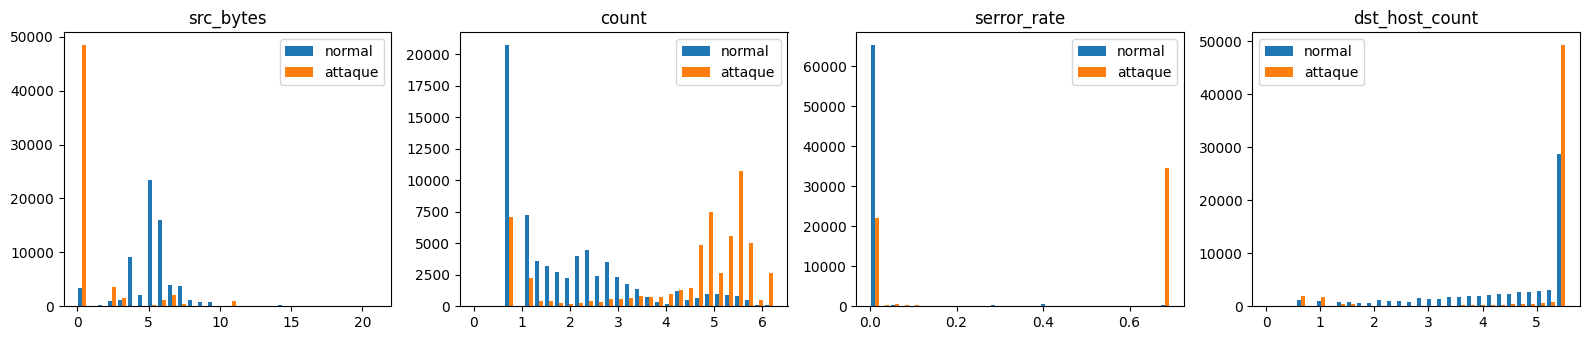

In [6]:
import numpy as np
cols = ["src_bytes", "count", "serror_rate", "dst_host_count"]
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
for a, c in zip(ax, cols):
    normal = train.loc[train.label == "normal", c]
    attack = train.loc[train.label != "normal", c]
    a.hist([np.log1p(normal), np.log1p(attack)], bins=30, label=["normal", "attaque"])
    a.set_title(c); a.legend()
plt.tight_layout(); plt.show()

## 6. Constats pour la suite
- Entraînement sur `normal` uniquement (≈ 67 343 lignes).
- Variables catégorielles à encoder : `protocol_type`, `service`, `flag`.
- Variables très asymétriques : normalisation nécessaire.
- `label` et `difficulty` ne doivent jamais servir de variables d'entrée.